# Sweep progress — `study_v2_plain_lvgp` (standard LVGP)
One bar per acquisition: **completed runs / 90** (90 = n_rep{3,5,10} × 30 seeds). Only the 3 noise-blind acquisitions (ei/lcb/pi) are swept here. Reads `results/` directly, so it works mid-sweep — **re-run the cell below to refresh** (Ctrl-Enter).

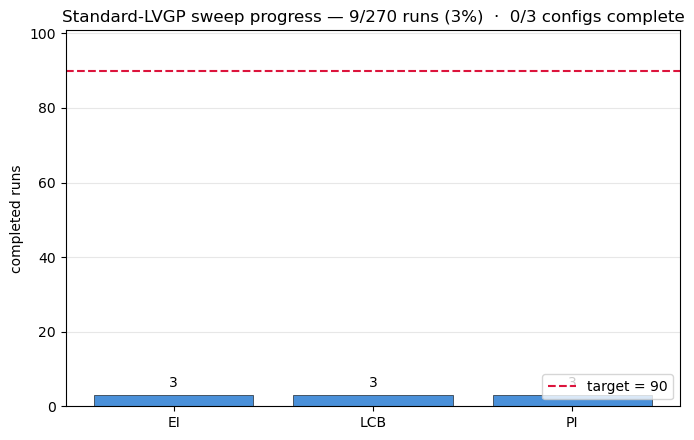

In [22]:
import glob, matplotlib.pyplot as plt
STUDY_DIR = "/data/zhq7531/IDEAL/hetero_lvgp/study_v2_plain_lvgp"
CONFIGS = ["ei", "lcb", "pi"]      # the 3 noise-blind acquisitions (plain LVGP)
TARGET = 90                         # 3 n_rep x 30 seeds per acquisition

counts = [len(glob.glob(f"{STUDY_DIR}/results/{c}/**/*.mat", recursive=True)) for c in CONFIGS]
done, total = sum(counts), TARGET * len(CONFIGS)
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#2e7d32" if c >= TARGET else "#4a90d9" for c in counts]
bars = ax.bar(range(len(CONFIGS)), counts, color=colors, edgecolor="k", lw=0.4)
ax.axhline(TARGET, color="crimson", ls="--", lw=1.5, label=f"target = {TARGET}")
for b, c in zip(bars, counts):
    ax.text(b.get_x()+b.get_width()/2, c + TARGET*0.015, str(c), ha="center", va="bottom", fontsize=10)
ax.set_xticks(range(len(CONFIGS))); ax.set_xticklabels([c.upper() for c in CONFIGS])
ax.set_ylim(0, TARGET*1.12); ax.set_ylabel("completed runs")
pct = 100*done/total if total else 0
ax.set_title(f"Standard-LVGP sweep progress \u2014 {done}/{total} runs ({pct:.0f}%)  \u00b7  "
             f"{sum(c >= TARGET for c in counts)}/{len(CONFIGS)} configs complete")
ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3); fig.tight_layout()